# Data Cleaning in Machine Learning

This notebook covers:
- Why data cleaning is needed in ML
- Handling missing values
- Removing or capping outliers
- Deduplication (removing duplicate rows)
- A simple end-to-end cleaning workflow

## 1) Why Data Cleaning is Important

Machine Learning models learn patterns from data.
If the data is noisy or wrong, model quality drops.

Common data quality issues:
- Missing values (`NaN`)
- Outliers (extreme values)
- Duplicate rows
- Wrong data types
- Inconsistent category labels

Rule: Better data -> Better model.

In [134]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 2) Create a Sample Dirty Dataset

This dataset intentionally includes:
- Missing values in `age`, `salary`, `city`
- Outlier in `salary`
- Duplicate rows

In [135]:
df = pd.DataFrame({
    "customer_id": [101, 102, 103, 104, 105, 105, 106, 107, 108, 109],
    "age": [25, np.nan, 30, 45, 29, 29, 40, np.nan, 34, 120],
    "salary": [35000, 42000, np.nan, 50000, 48000, 48000, 1500000, 52000, np.nan, 61000],
    "city": ["Delhi", "Mumbai", "Delhi", None, "Pune", "Pune", "Delhi", "Mumbai", "Pune", None],
    "bought": [1, 0, 1, 0, 1, 1, 1, 0, 0, 1]
})

df

,customer_id,age,salary,city,bought
0,101,25.0,35000.0,Delhi,1
1,102,NaN,42000.0,Mumbai,0
2,103,30.0,NaN,Delhi,1
3,104,45.0,50000.0,NaN,0
4,105,29.0,48000.0,Pune,1
5,105,29.0,48000.0,Pune,1
6,106,40.0,1500000.0,Delhi,1
7,107,NaN,52000.0,Mumbai,0
8,108,34.0,NaN,Pune,0
9,109,120.0,61000.0,NaN,1


In [136]:
# Quick data inspection
print("Shape:", df.shape)
print("\nMissing values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df.describe(include="all").round(2)

Shape: (10, 5)

Missing values per column:

customer_id    0
age            2
salary         2
city           2
bought         0
dtype: int64

Duplicate rows: 1


,customer_id,age,salary,city,bought
count,10.00,8.00,8.00,8,10.00
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,Delhi,NaN
freq,NaN,NaN,NaN,3,NaN
mean,105.00,44.00,229500.00,NaN,0.60
std,2.58,31.40,513414.34,NaN,0.52
min,101.00,25.00,35000.00,NaN,0.00
25%,103.25,29.00,46500.00,NaN,0.00
50%,105.00,32.00,49000.00,NaN,1.00
75%,106.75,41.25,54250.00,NaN,1.00


## 3) Handling Missing Values

### Common strategies
- Drop rows/columns (simple, but data loss)
- Fill numeric with mean/median
- Fill categorical with mode (most common value)
- Advanced methods: model-based imputation

For beginners, median (numeric) + mode (categorical) is a strong baseline.

In [137]:
# Why median is safer than mean when outliers exist (salary example)
print("Salary mean   :", round(df["salary"].mean(), 2))
print("Salary median :", round(df["salary"].median(), 2))

print("\nBecause of extreme salary values, mean shifts more than median.")
print("So for this dataset, median imputation is the safer choice for salary.")

Salary mean   : 229500.0
Salary median : 49000.0

Because of extreme salary values, mean shifts more than median.
So for this dataset, median imputation is the safer choice for salary.


In [138]:
# Compare imputation values side-by-side for easy understanding
imputation_table = pd.DataFrame({
    "column": ["age", "salary", "city"],
    "dtype": [str(df["age"].dtype), str(df["salary"].dtype), str(df["city"].dtype)],
    "missing_count": [df["age"].isnull().sum(), df["salary"].isnull().sum(), df["city"].isnull().sum()],
    "mean": [df["age"].mean(), df["salary"].mean(), np.nan],
    "median": [df["age"].median(), df["salary"].median(), np.nan],
    "mode": [df["age"].mode()[0], df["salary"].mode()[0], df["city"].mode()[0]], # there can be multiple strings with the same mode for ex - in a dataset apple and banana both appear for 10 times so mode returns a series of data so we have to do [0] which will tell python to pick the first one with highest frequency
    "recommended_here": ["median", "median", "mode"]
})

imputation_table

,column,dtype,missing_count,mean,median,mode,recommended_here
0,age,float64,2,44.0,32.0,29.0,median
1,salary,float64,2,229500.0,49000.0,48000.0,median
2,city,str,2,NaN,NaN,Delhi,mode


### When to use Mean, Median, and Mode (Quick Decision Table)

| Method | Best for | Use when | Avoid when | Example columns |
|---|---|---|---|---|
| Mean | Numeric | Data is fairly symmetric (normal-like), no strong outliers | Outliers are present (mean gets pulled) | height, exam_score |
| Median | Numeric | Data is skewed or has outliers | Very small data where center is unstable | income, salary, house_price |
| Mode | Categorical (or discrete) | Filling missing categories with most frequent class | Category distribution is very noisy/imbalanced without domain check | city, gender, product_type |

Practical rule in ML projects:
- Numeric + outliers/skew -> prefer **median**
- Numeric + clean symmetric data -> **mean** is fine
- Categorical -> use **mode**

In [139]:
# Method A: Drop rows having any missing value (easy but can remove too much data)
df_dropna = df.dropna()
print("Original shape:", df.shape)
print("After dropna shape:", df_dropna.shape)
print(df)
print(df_dropna)

Original shape: (10, 5)
After dropna shape: (4, 5)
   customer_id    age     salary    city  bought
0          101   25.0    35000.0   Delhi       1
1          102    NaN    42000.0  Mumbai       0
2          103   30.0        NaN   Delhi       1
3          104   45.0    50000.0     NaN       0
4          105   29.0    48000.0    Pune       1
5          105   29.0    48000.0    Pune       1
6          106   40.0  1500000.0   Delhi       1
7          107    NaN    52000.0  Mumbai       0
8          108   34.0        NaN    Pune       0
9          109  120.0    61000.0     NaN       1
   customer_id   age     salary   city  bought
0          101  25.0    35000.0  Delhi       1
4          105  29.0    48000.0   Pune       1
5          105  29.0    48000.0   Pune       1
6          106  40.0  1500000.0  Delhi       1


In [140]:
# Method B: Impute missing values (recommended in many cases)
df_imputed = df.copy()

# Numeric columns: median is robust to outliers
df_imputed["age"] = df_imputed["age"].fillna(df_imputed["age"].median())
df_imputed["salary"] = df_imputed["salary"].fillna(df_imputed["salary"].median())

# Categorical column: mode (most frequent value)
df_imputed["city"] = df_imputed["city"].fillna(df_imputed["city"].mode()[0])

print("Missing values after imputation:\n")
print(df_imputed.isnull().sum())

df_imputed.head()

Missing values after imputation:

customer_id    0
age            0
salary         0
city           0
bought         0
dtype: int64


,customer_id,age,salary,city,bought
0,101,25.0,35000.0,Delhi,1
1,102,32.0,42000.0,Mumbai,0
2,103,30.0,49000.0,Delhi,1
3,104,45.0,50000.0,Delhi,0
4,105,29.0,48000.0,Pune,1


## 4) Outlier Detection and Treatment

Outliers are extreme values far from normal range.
They can heavily affect models like Linear Regression and KNN.

Common methods:
- IQR (Inter Quartile Range) method (good and simple)
- Z-score method
- Log transform / capping (winsorization)

We will use IQR and then cap the outliers.

In [141]:
# IQR boundaries for salary
Q1 = df_imputed["salary"].quantile(0.25)
Q3 = df_imputed["salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# any data point less than lower bound will be considered as low outliers and higher than upper bound will be considered as high outliers 

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 48000.0
Q3: 51500.0
IQR: 3500.0
Lower bound: 42750.0
Upper bound: 56750.0


In [142]:
# See rows that are outliers in salary
salary_outliers = df_imputed[(df_imputed["salary"] < lower_bound) | (df_imputed["salary"] > upper_bound)]
print("Number of salary outliers:", len(salary_outliers))
salary_outliers

Number of salary outliers: 4


,customer_id,age,salary,city,bought
0,101,25.0,35000.0,Delhi,1
1,102,32.0,42000.0,Mumbai,0
6,106,40.0,1500000.0,Delhi,1
9,109,120.0,61000.0,Delhi,1


In [143]:
# Option 1: Remove outlier rows
df_no_outliers = df_imputed[(df_imputed["salary"] >= lower_bound) & (df_imputed["salary"] <= upper_bound)].copy()

print("Shape before removing outliers:", df_imputed.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

df_no_outliers.head()

Shape before removing outliers: (10, 5)
Shape after removing outliers: (6, 5)


,customer_id,age,salary,city,bought
2,103,30.0,49000.0,Delhi,1
3,104,45.0,50000.0,Delhi,0
4,105,29.0,48000.0,Pune,1
5,105,29.0,48000.0,Pune,1
7,107,32.0,52000.0,Mumbai,0


In [ ]:
# Option 2: Cap outliers instead of removing rows (winsorization style)

# in this method we cap the outliers meaning we replace the low outliers with the lower bound and high outliers with the upper bound

df_capped = df_imputed.copy()
df_capped["salary"] = df_capped["salary"].clip(lower=lower_bound, upper=upper_bound) # this will replacec value lesser than the lower , by lower and value higher than the upper by upper

print("Max salary before capping:", df_imputed["salary"].max())
print("Max salary after capping:", df_capped["salary"].max()) # equals to lower_bound
print("Min salary before capping:", df_imputed["salary"].min())
print("Min salary after capping:", df_capped["salary"].min()) # equals to upper_bound

df_capped.head()

Max salary before capping: 1500000.0
Max salary after capping: 56750.0
Min salary before capping: 35000.0
Min salary after capping: 42750.0


,customer_id,age,salary,city,bought
0,101,25.0,42750.0,Delhi,1
1,102,32.0,42750.0,Mumbai,0
2,103,30.0,49000.0,Delhi,1
3,104,45.0,50000.0,Delhi,0
4,105,29.0,48000.0,Pune,1


### 4.1 Graphical Outlier Detection (Easy and Practical)

Different plots help in different situations:
- **Boxplot**: Best quick method for univariate outlier detection
- **Histogram**: Helps see skewness and long tails
- **Scatter plot**: Helps detect unusual points in relationship between two variables

We will use these on `age` and `salary`.

In [145]:
import matplotlib.pyplot as plt

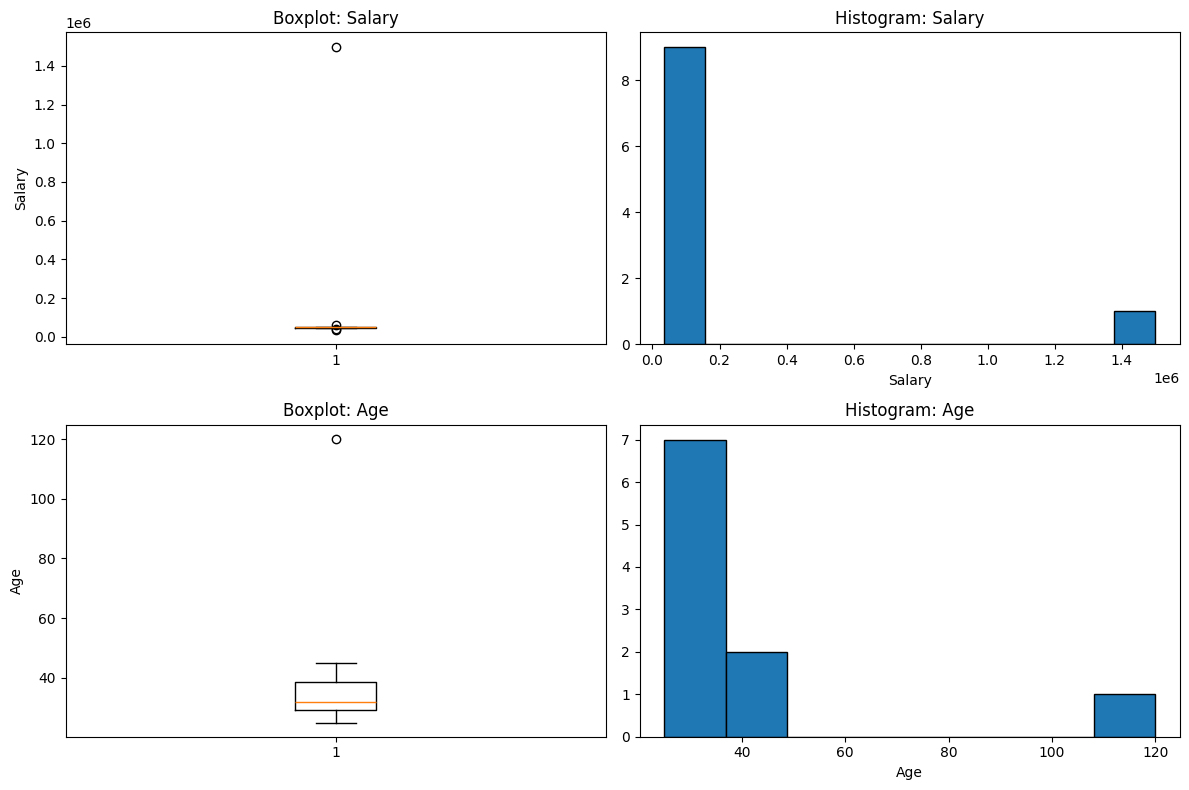

In [146]:
# Boxplot + Histogram for univariate outlier detection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Salary
axes[0, 0].boxplot(df_imputed["salary"], vert=True)
axes[0, 0].set_title("Boxplot: Salary")
axes[0, 0].set_ylabel("Salary")

axes[0, 1].hist(df_imputed["salary"], bins=12, edgecolor="black")
axes[0, 1].set_title("Histogram: Salary")
axes[0, 1].set_xlabel("Salary")

# Age
axes[1, 0].boxplot(df_imputed["age"], vert=True)
axes[1, 0].set_title("Boxplot: Age")
axes[1, 0].set_ylabel("Age")

axes[1, 1].hist(df_imputed["age"], bins=8, edgecolor="black")
axes[1, 1].set_title("Histogram: Age")
axes[1, 1].set_xlabel("Age")

plt.tight_layout()
plt.show()

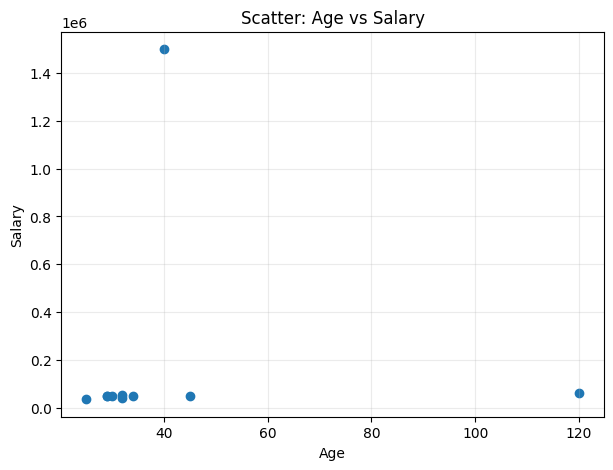

In [147]:
# Scatter plot for bivariate pattern check (Age vs Salary)
plt.figure(figsize=(7, 5))
plt.scatter(df_imputed["age"], df_imputed["salary"])
plt.title("Scatter: Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(alpha=0.25)
plt.show()

In [148]:
# Outlier method summary table (quick revision)
outlier_summary = pd.DataFrame([
    ["Boxplot", "Univariate quick check", "Shows points beyond whiskers", "Fast and intuitive"],
    ["Histogram", "Distribution and skewness", "Long tails/extreme bins", "Useful with boxplot"],
    ["Scatter plot", "Two-variable pattern", "Unusual isolated points", "Good for relationship outliers"],
    ["IQR rule", "Skewed/non-normal numeric", "Outside [Q1-1.5*IQR, Q3+1.5*IQR]", "Robust baseline"],
    ["Z-score", "Approximately normal numeric", "|z| > 3", "Sensitive to non-normal data"],
    ["Treatment: Remove", "Clear bad records", "Drop outlier rows", "Risk: data loss"],
    ["Treatment: Cap", "Keep rows, reduce effect", "Clip to bounds", "Common in production"],
    ["Treatment: Log", "Right-skewed positives", "Apply log1p", "Reduces skew and extreme impact"]
], columns=["Method", "Best for", "How it detects / treats", "Notes"])

outlier_summary

,Method,Best for,How it detects / treats,Notes
0,Boxplot,Univariate quick check,Shows points beyond whiskers,Fast and intuitive
1,Histogram,Distribution and skewness,Long tails/extreme bins,Useful with boxplot
2,Scatter plot,Two-variable pattern,Unusual isolated points,Good for relationship outliers
3,IQR rule,Skewed/non-normal numeric,"Outside [Q1-1.5*IQR, Q3+1.5*IQR]",Robust baseline
4,Z-score,Approximately normal numeric,|z| > 3,Sensitive to non-normal data
5,Treatment: Remove,Clear bad records,Drop outlier rows,Risk: data loss
6,Treatment: Cap,"Keep rows, reduce effect",Clip to bounds,Common in production
7,Treatment: Log,Right-skewed positives,Apply log1p,Reduces skew and extreme impact


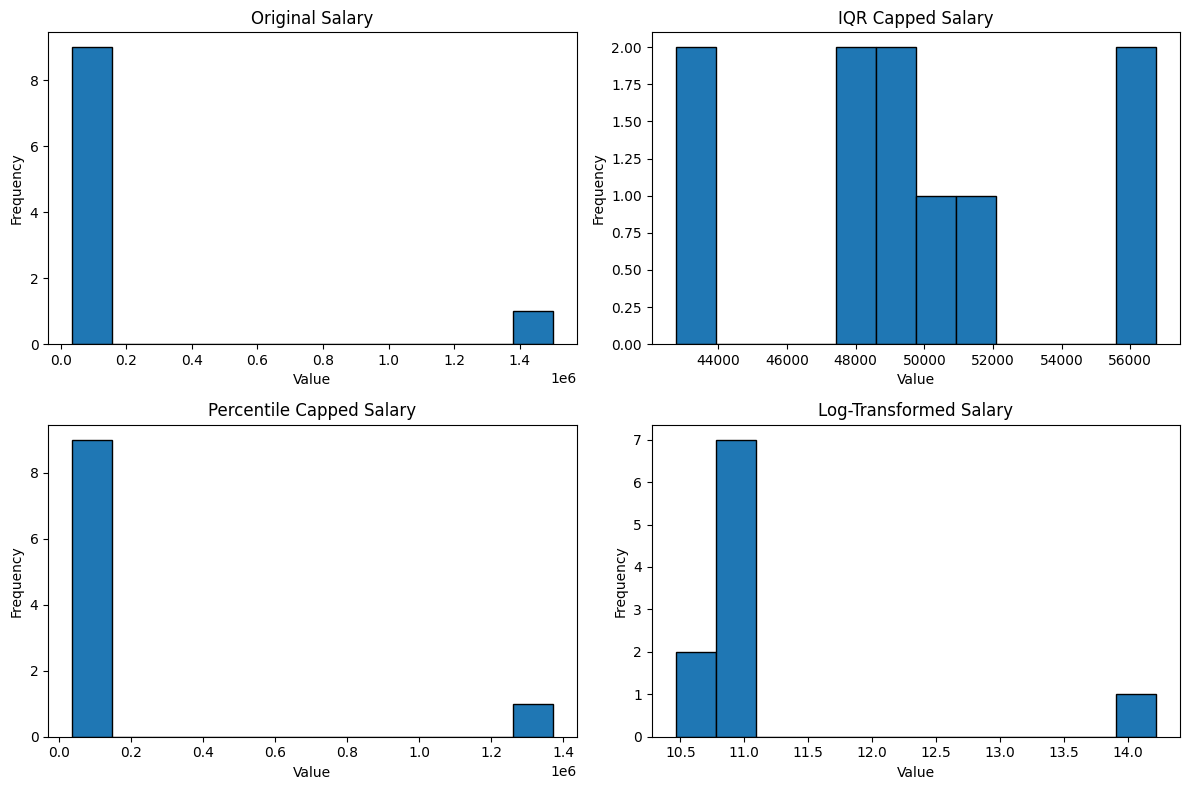

In [149]:
# Easy visual comparison of outlier treatments on salary

plot_base_df = df_imputed.copy()

plot_q1 = plot_base_df["salary"].quantile(0.25)
plot_q3 = plot_base_df["salary"].quantile(0.75)
plot_iqr = plot_q3 - plot_q1
plot_low_iqr = plot_q1 - 1.5 * plot_iqr
plot_high_iqr = plot_q3 + 1.5 * plot_iqr

plot_capped_iqr_df = plot_base_df.copy()
plot_capped_iqr_df["salary"] = plot_capped_iqr_df["salary"].clip(plot_low_iqr, plot_high_iqr)

plot_p01 = plot_base_df["salary"].quantile(0.01)
plot_p99 = plot_base_df["salary"].quantile(0.99)
plot_capped_pct_df = plot_base_df.copy()
plot_capped_pct_df["salary"] = plot_capped_pct_df["salary"].clip(plot_p01, plot_p99)

plot_log_df = plot_base_df.copy()
plot_log_df["salary_log1p"] = np.log1p(plot_log_df["salary"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(plot_base_df["salary"], bins=12, edgecolor="black")
axes[0, 0].set_title("Original Salary")

axes[0, 1].hist(plot_capped_iqr_df["salary"], bins=12, edgecolor="black")
axes[0, 1].set_title("IQR Capped Salary")

axes[1, 0].hist(plot_capped_pct_df["salary"], bins=12, edgecolor="black")
axes[1, 0].set_title("Percentile Capped Salary")

axes[1, 1].hist(plot_log_df["salary_log1p"], bins=12, edgecolor="black")
axes[1, 1].set_title("Log-Transformed Salary")

for ax in axes.flat:
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [150]:
# Treatment examples on salary using df_imputed (clear variable names)
salary_base_df = df_imputed.copy()

# 1) Detect outlier bounds using IQR
salary_q1 = salary_base_df["salary"].quantile(0.25)
salary_q3 = salary_base_df["salary"].quantile(0.75)
salary_iqr = salary_q3 - salary_q1
salary_low_iqr = salary_q1 - 1.5 * salary_iqr
salary_high_iqr = salary_q3 + 1.5 * salary_iqr

# 2) Remove outlier rows
salary_outlier_mask = (salary_base_df["salary"] < salary_low_iqr) | (salary_base_df["salary"] > salary_high_iqr)
salary_removed_df = salary_base_df.loc[~salary_outlier_mask].copy()

# 3) IQR capping
salary_capped_iqr_df = salary_base_df.copy()
salary_capped_iqr_df["salary"] = salary_capped_iqr_df["salary"].clip(salary_low_iqr, salary_high_iqr)

# 4) Percentile capping (1st to 99th percentile)
salary_p01 = salary_base_df["salary"].quantile(0.01)
salary_p99 = salary_base_df["salary"].quantile(0.99)
salary_capped_pct_df = salary_base_df.copy()
salary_capped_pct_df["salary"] = salary_capped_pct_df["salary"].clip(salary_p01, salary_p99)

# 5) Log transform (helps with right-skewed values)
salary_log_df = salary_base_df.copy()
salary_log_df["salary_log1p"] = np.log1p(salary_log_df["salary"])

print("Original max salary:", salary_base_df["salary"].max().round(2))
print("After IQR capping max salary:", salary_capped_iqr_df["salary"].max().round(2))
print("After percentile capping max salary:", salary_capped_pct_df["salary"].max().round(2))
print("Rows after outlier removal:", salary_removed_df.shape[0], "from", salary_base_df.shape[0])

Original max salary: 1500000.0
After IQR capping max salary: 56750.0
After percentile capping max salary: 1370490.0
Rows after outlier removal: 6 from 10


### 4.2 How to Choose Outlier Treatment (Condition Based)

Use this practical guide:
- **Very few clear data-entry errors** -> Remove those rows
- **Valid extreme values, but you want to keep rows** -> Cap values (IQR/percentile capping)
- **Heavy right-skewed numeric feature** -> Log transform can reduce skew
- **Tree-based models (RF/XGBoost)** -> Usually less sensitive, mild outliers may be okay
- **Linear/KNN/SVM** -> Usually more sensitive, treat outliers carefully

In [151]:
# Helper functions for outlier detection
def iqr_outlier_mask(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return (series < low) | (series > high), low, high

def zscore_outlier_mask(series, threshold=3.0):
    mean = series.mean()
    std = series.std(ddof=0)
    z = (series - mean) / std
    return z.abs() > threshold

salary_iqr_mask, salary_low, salary_high = iqr_outlier_mask(df_imputed["salary"])
salary_z_mask = zscore_outlier_mask(df_imputed["salary"], threshold=3)

print("IQR outliers in salary:", salary_iqr_mask.sum())
print("Z-score outliers in salary:", salary_z_mask.sum())
print("IQR bounds:", round(salary_low, 2), "to", round(salary_high, 2))

IQR outliers in salary: 4
Z-score outliers in salary: 0
IQR bounds: 42750.0 to 56750.0


## 5) Deduplication (Removing Duplicate Rows)

Duplicates can bias model learning.
If one record appears multiple times by mistake, it gets extra weight.

`drop_duplicates()` removes repeated rows.

In [152]:
# Deduplication on capped dataset
df_dedup = df_capped.drop_duplicates().copy()

print("Shape before dedup:", df_capped.shape)
print("Shape after dedup:", df_dedup.shape)
print("Duplicates remaining:", df_dedup.duplicated().sum())

df_dedup

Shape before dedup: (10, 5)
Shape after dedup: (9, 5)
Duplicates remaining: 0


,customer_id,age,salary,city,bought
0,101,25.0,42750.0,Delhi,1
1,102,32.0,42750.0,Mumbai,0
2,103,30.0,49000.0,Delhi,1
3,104,45.0,50000.0,Delhi,0
4,105,29.0,48000.0,Pune,1
6,106,40.0,56750.0,Delhi,1
7,107,32.0,52000.0,Mumbai,0
8,108,34.0,49000.0,Pune,0
9,109,120.0,56750.0,Delhi,1


## 6) Final Clean Dataset (Ready for ML)

Our final steps:
1. Handle missing values (median/mode)
2. Treat outliers (capping)
3. Remove duplicates

Now we create one reusable cleaned dataframe.

In [153]:
# End-to-end cleaning function (easy to reuse)
def clean_data(input_df):
    data = input_df.copy()

    # 1) Missing values
    data["age"] = data["age"].fillna(data["age"].median())
    data["salary"] = data["salary"].fillna(data["salary"].median())
    data["city"] = data["city"].fillna(data["city"].mode()[0])

    # 2) Outlier capping on salary using IQR
    q1 = data["salary"].quantile(0.25)
    q3 = data["salary"].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    data["salary"] = data["salary"].clip(low, high)

    # 3) Remove duplicates
    data = data.drop_duplicates()

    return data

clean_df = clean_data(df)

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)
print("\nMissing values after cleaning:\n", clean_df.isnull().sum())
print("\nDuplicate rows after cleaning:", clean_df.duplicated().sum())

clean_df

Original shape: (10, 5)
Cleaned shape: (9, 5)

Missing values after cleaning:
 customer_id    0
age            0
salary         0
city           0
bought         0
dtype: int64

Duplicate rows after cleaning: 0


,customer_id,age,salary,city,bought
0,101,25.0,42750.0,Delhi,1
1,102,32.0,42750.0,Mumbai,0
2,103,30.0,49000.0,Delhi,1
3,104,45.0,50000.0,Delhi,0
4,105,29.0,48000.0,Pune,1
6,106,40.0,56750.0,Delhi,1
7,107,32.0,52000.0,Mumbai,0
8,108,34.0,49000.0,Pune,0
9,109,120.0,56750.0,Delhi,1


## 7) Quick Interview Notes

- Why clean data?
: To improve model quality and reduce bias/noise.
- Missing values handling?
: Drop, mean/median/mode imputation, advanced imputation.
- Outlier handling?
: Remove, cap, transform, or robust models.
- Deduplication?
: Prevent duplicate records from distorting model learning.

## 8) Mini Practice

Try on your own:
1. Add one more outlier in `age` and treat it with IQR.
2. Create a column with inconsistent city names (`delhi`, `DELHI`) and standardize it.
3. Compare model performance before and after cleaning.